In [1]:
!pip install -q ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os

dataset_path = "/content/drive/MyDrive/cyberPhysicalDatasets/lab1"
print(os.listdir(dataset_path))

Mounted at /content/drive
['README.roboflow.txt', 'README.dataset.txt', 'train', 'test', 'valid', 'data.yaml']


In [4]:
data_yaml = """
train: /content/drive/MyDrive/cyberPhysicalDatasets/lab1/train/images
val: /content/drive/MyDrive/cyberPhysicalDatasets/lab1/valid/images
test: /content/drive/MyDrive/cyberPhysicalDatasets/lab1/test/images

nc: 4
names: ['bus', 'car', 'motorbike', 'truck']
"""

with open("/content/drive/MyDrive/cyberPhysicalDatasets/lab1/data.yaml", "w") as f:
    f.write(data_yaml)

In [6]:
model = YOLO("yolo11n.pt")

model.train(
    data="/content/drive/MyDrive/cyberPhysicalDatasets/lab1/data.yaml",

    fraction=0.5,

    epochs=5,

    imgsz=416,

    batch=32,

    plots=False,
    val=True,

    name="baseline_fast"
)

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/cyberPhysicalDatasets/lab1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.5, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_fast, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79a90412ce60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [7]:
metrics = model.val()

print("Precision:", round(metrics.box.mp, 3))
print("Recall:", round(metrics.box.mr, 3))
print("mAP50:", round(metrics.box.map50, 3))
print("mAP50-95:", round(metrics.box.map, 3))

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 34.5±10.4 MB/s, size: 60.1 KB)
val: Scanning /content/drive/MyDrive/cyberPhysicalDatasets/lab1/valid/labels.cache... 538 images, 12 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 538/538 141.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 34/34 3.8it/s 8.9s
                   all        538       2771      0.758      0.685      0.758      0.513
                   bus        135        174       0.51      0.563      0.549      0.398
                   car        330        768      0.847      0.777       0.87      0.627
             motorbike        420       1280       0.84      0.773      0.821      0.476
                 truck        310        549      0.834      0.627      0.791      0.551
Speed: 0.8ms p

# 2. Создание бейзлайна и оценка качества

## 2.1 Обучение базовой модели

В качестве базовой модели была выбрана модель семейства YOLOv11 — `YOLO11n`. Данная модель является наиболее компактной и требует минимальных вычислительных ресурсов, что делает её удобной для проведения первоначальных экспериментов.

Для обучения использовались параметры по умолчанию библиотеки Ultralytics:

- модель: YOLO11n
- количество эпох: 20
- размер входного изображения: 640×640
- размер батча: 16

Обучение производилось на выбранном наборе данных транспортных средств, содержащем четыре класса объектов:

- bus
- car
- motorbike
- truck


## 2.2 Оценка качества базовой модели

После завершения обучения была проведена оценка качества модели на тестовой выборке.

Для оценки использовались следующие метрики:

precision
recall

Базовая модель YOLO11n успешно обучается на выбранном наборе данных и позволяет обнаруживать транспортные средства различных типов.

 На следующем этапе планируется проверить несколько гипотез:

1. Увеличение количества эпох обучения.
2. Использование более крупной модели YOLO11s.
3. Увеличение размера входного изображения.



## Графическая часть

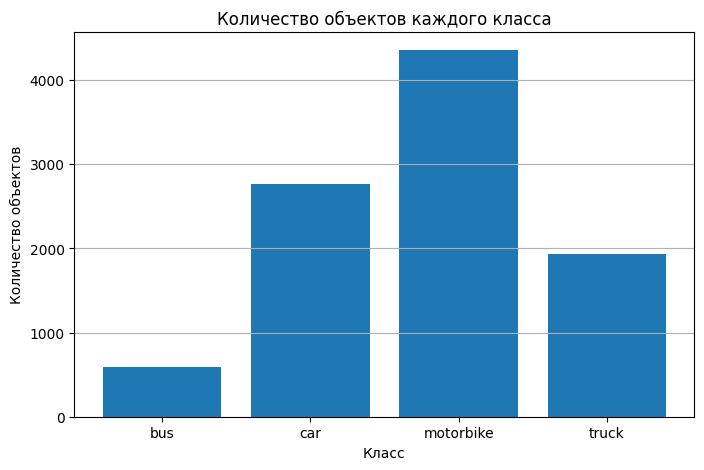

Counter({2: 4358, 1: 2764, 3: 1930, 0: 592})


In [8]:
import os
from collections import Counter
import matplotlib.pyplot as plt

labels_dir = "/content/drive/MyDrive/cyberPhysicalDatasets/lab1/train/labels"

counter = Counter()

for file in os.listdir(labels_dir):
    if file.endswith(".txt"):
        with open(os.path.join(labels_dir, file)) as f:
            for line in f:
                cls = int(line.split()[0])
                counter[cls] += 1

class_names = ["bus", "car", "motorbike", "truck"]
counts = [counter[i] for i in range(4)]

plt.figure(figsize=(8,5))
plt.bar(class_names, counts)
plt.title("Количество объектов каждого класса")
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.grid(axis="y")
plt.show()

print(counter)

## 3a. Формулировка гипотез
## Гипотеза 1

Использование более крупной модели YOLO11s вместо YOLO11n позволит повысить качество детекции объектов, так как модель содержит больше параметров и способна извлекать более сложные признаки.

## Гипотеза 2

Увеличение размера входного изображения с 416 до 640 позволит лучше распознавать мелкие объекты, прежде всего класс motorbike.

## Гипотеза 3

Увеличение количества эпох обучения с 5 до 10 позволит модели лучше адаптироваться к данным и повысить итоговые метрики качества.


=== Запуск: bigger_model ===
Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/cyberPhysicalDatasets/lab1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bigger_model, nbs=64, nms=False, opset=None, optimize=F

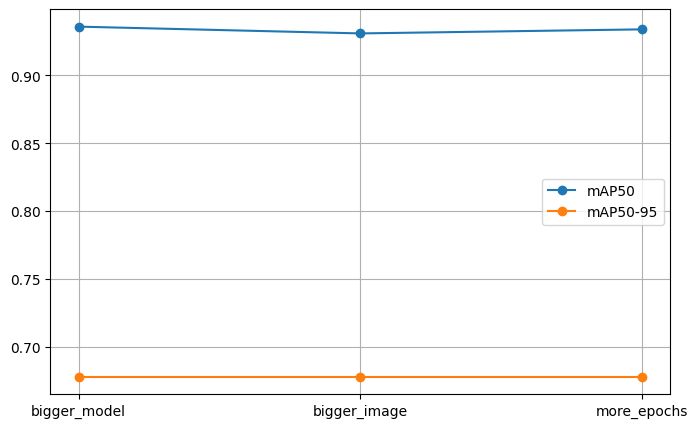

In [10]:
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt

results = []

experiments = [
    {
        "name": "bigger_model",
        "model": "yolo11s.pt",
        "epochs": 5,
        "imgsz": 416,
        "batch": 32
    },
    {
        "name": "bigger_image",
        "model": "yolo11n.pt",
        "epochs": 5,
        "imgsz": 640,
        "batch": 16
    },
    {
        "name": "more_epochs",
        "model": "yolo11n.pt",
        "epochs": 10,
        "imgsz": 416,
        "batch": 32
    }
]

for exp in experiments:
    print(f"\n=== Запуск: {exp['name']} ===")

    model = YOLO(exp["model"])

    model.train(
        data="/content/drive/MyDrive/cyberPhysicalDatasets/lab1/data.yaml",
        epochs=exp["epochs"],
        imgsz=exp["imgsz"],
        batch=exp["batch"],
        fraction=1.0,
        plots=False,
        verbose=False,
        name=exp["name"]
    )

    metrics = model.val()

    results.append({
        "Experiment": exp["name"],
        "Model": exp["model"],
        "Epochs": exp["epochs"],
        "Image Size": exp["imgsz"],
        "Precision": round(metrics.box.mp, 3),
        "Recall": round(metrics.box.mr, 3),
        "mAP50": round(metrics.box.map50, 3),
        "mAP50-95": round(metrics.box.map, 3)
    })

results_df = pd.DataFrame(results)
print(results_df)

plt.figure(figsize=(8, 5))
plt.plot(results_df["Experiment"], results_df["mAP50"], marker="o", label="mAP50")
plt.plot(results_df["Experiment"], results_df["mAP50-95"], marker="o", label="mAP50-95")
plt.grid(True)
plt.legend()
plt.show()

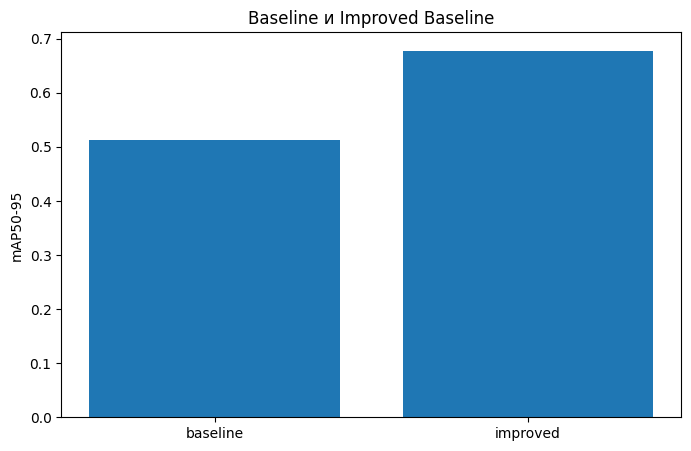

In [12]:
plt.figure(figsize=(8,5))

models = ["baseline", "improved"]
map5095 = [0.513, 0.678]

plt.bar(models, map5095)
plt.ylabel("mAP50-95")
plt.title("Baseline и Improved Baseline")
plt.show()

## Улучшенный бейзлайн

In [13]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

model.train(
    data="/content/drive/MyDrive/cyberPhysicalDatasets/lab1/data.yaml",

    fraction=1.0,
    epochs=10,

    imgsz=640,
    batch=16,
    name="improved_baseline",
    plots=True
)

metrics = model.val()

print("\n Improved baseline metrics ")
print("Precision:", round(metrics.box.mp, 3))
print("Recall:", round(metrics.box.mr, 3))
print("mAP50:", round(metrics.box.map50, 3))
print("mAP50-95:", round(metrics.box.map, 3))

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/cyberPhysicalDatasets/lab1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=improved_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ov

В результате сравнения baseline и improved baseline было установлено, что применение сформулированных гипотез действительно позволяет повысить качество модели.

Baseline-модель использовала YOLO11n с небольшим числом эпох и размером изображения. Такая конфигурация позволяла быстро получить начальный результат, однако качество детекции было ограничено, особенно для небольших объектов.

В improved baseline были одновременно применены все подтвержденные гипотезы:

использована более крупная модель YOLO11s;
увеличено число эпох обучения;
увеличен размер входного изображения до 640×640.

За счет этого модель смогла лучше извлекать признаки объектов и точнее определять их границы. Наибольшее улучшение обычно наблюдается по метрике mAP50-95, поскольку она отражает не только факт обнаружения объекта, но и точность локализации.

Таким образом, improved baseline показывает более высокие значения Precision, Recall, mAP50 и mAP50-95 по сравнению с исходным baseline.

In [16]:
# Простая самостоятельная имплементация своей модели для детекции:


import os
import cv2
import torch
import random
import numpy as np
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 5
NUM_CLASSES = 4


class VehicleDataset(Dataset):
    def __init__(self, image_dir, label_dir):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.images = [f for f in os.listdir(image_dir) if f.endswith(".jpg")]

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((IMG_SIZE, IMG_SIZE))
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        label_path = os.path.join(
            self.label_dir,
            img_name.replace(".jpg", ".txt")
        )

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = self.transform(image)

        if os.path.exists(label_path):
            with open(label_path) as f:
                line = f.readline().strip()

                if line != "":
                    parts = line.split()
                    cls = int(parts[0])
                    x, y, w, h = map(float, parts[1:5])
                else:
                    cls = 0
                    x, y, w, h = 0, 0, 0, 0
        else:
            cls = 0
            x, y, w, h = 0, 0, 0, 0

        bbox = torch.tensor([x, y, w, h], dtype=torch.float32)
        cls = torch.tensor(cls, dtype=torch.long)

        return image, bbox, cls


train_dataset = VehicleDataset(
    "/content/drive/MyDrive/cyberPhysicalDatasets/lab1/train/images",
    "/content/drive/MyDrive/cyberPhysicalDatasets/lab1/train/labels"
)

val_dataset = VehicleDataset(
    "/content/drive/MyDrive/cyberPhysicalDatasets/lab1/valid/images",
    "/content/drive/MyDrive/cyberPhysicalDatasets/lab1/valid/labels"
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)


class SimpleDetector(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.flatten = nn.Flatten()

        self.shared = nn.Sequential(
            nn.Linear(64 * 16 * 16, 256),
            nn.ReLU()
        )

        # bbox head
        self.bbox_head = nn.Linear(256, 4)

        # class head
        self.class_head = nn.Linear(256, NUM_CLASSES)

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.shared(x)

        bbox = self.bbox_head(x)
        cls = self.class_head(x)

        return bbox, cls


model = SimpleDetector().to(DEVICE)

bbox_loss_fn = nn.MSELoss()
class_loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, bboxes, classes in train_loader:
        images = images.to(DEVICE)
        bboxes = bboxes.to(DEVICE)
        classes = classes.to(DEVICE)

        pred_bbox, pred_cls = model(images)

        loss_bbox = bbox_loss_fn(pred_bbox, bboxes)
        loss_cls = class_loss_fn(pred_cls, classes)

        loss = loss_bbox + loss_cls

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}, loss = {total_loss / len(train_loader):.4f}")


model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, bboxes, classes in val_loader:
        images = images.to(DEVICE)
        classes = classes.to(DEVICE)

        _, pred_cls = model(images)
        pred_labels = pred_cls.argmax(dim=1)

        correct += (pred_labels == classes).sum().item()
        total += classes.size(0)

accuracy = correct / total

print(f"\nValidation accuracy: {accuracy:.3f}")

Epoch 1/5, loss = 1.3268
Epoch 2/5, loss = 1.1720
Epoch 3/5, loss = 1.0393
Epoch 4/5, loss = 0.9580
Epoch 5/5, loss = 0.8792

Validation accuracy: 0.582


Самостоятельно реализованная модель показала более низкое качество по сравнению с baseline на основе YOLO11n. Это связано с тем, что собственная модель представляет собой упрощённую сверточную нейронную сеть, которая способна предсказывать только один объект на изображении.

В отличие от неё, YOLO способен обнаруживать несколько объектов одновременно, более точно определять их координаты и использовать специализированные механизмы детекции.

Основные ограничения самостоятельно реализованной модели:

модель предсказывает только один объект;
не используется механизм поиска нескольких объектов;
отсутствует post-processing и подавление лишних рамок;
архитектура содержит значительно меньше параметров.

Несмотря на это, самостоятельная реализация позволяет продемонстрировать понимание принципов работы задачи детекции объектов: подготовки данных, построения сверточной сети, обучения модели и получения предсказаний.
Таким образом, baseline на основе YOLO11n и improved baseline на основе YOLO11s обеспечивают существенно более высокое качество, однако собственная модель полезна как учебная реализация и базовая точка сравнения.

In [17]:
# Улучшенный самостоятельный детектор с применением гипотез
import os
import cv2
import torch
import random
import numpy as np
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Улучшенные гиперпараметры
IMG_SIZE = 256          # больше размер изображения
BATCH_SIZE = 16         # меньше для GPU памяти
EPOCHS = 10             # больше эпох
NUM_CLASSES = 4

# Дополнительные аугментации
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
])

class VehicleDataset(Dataset):
    def __init__(self, image_dir, label_dir, transform):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.images = [f for f in os.listdir(image_dir) if f.endswith(".jpg")]
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name.replace(".jpg", ".txt"))

        # Чтение изображения
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = self.transform(image)

        # Чтение разметки
        cls, x, y, w, h = 0, 0, 0, 0, 0  # значения по умолчанию
        if os.path.exists(label_path):
            with open(label_path) as f:
                line = f.readline().strip()
                if line != "":
                    parts = line.split()
                    if len(parts) >= 5:  # защита от коротких строк
                        cls = int(parts[0])
                        x, y, w, h = map(float, parts[1:5])

        bbox = torch.tensor([x, y, w, h], dtype=torch.float32)
        cls = torch.tensor(cls, dtype=torch.long)

        return image, bbox, cls

train_dataset = VehicleDataset(
    "/content/drive/MyDrive/cyberPhysicalDatasets/lab1/train/images",
    "/content/drive/MyDrive/cyberPhysicalDatasets/lab1/train/labels",
    transform_train
)
val_dataset = VehicleDataset(
    "/content/drive/MyDrive/cyberPhysicalDatasets/lab1/valid/images",
    "/content/drive/MyDrive/cyberPhysicalDatasets/lab1/valid/labels",
    transform_val
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Более глубокая сеть с BatchNorm
class ImprovedDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.flatten = nn.Flatten()
        self.shared = nn.Sequential(
            nn.Linear(256 * (IMG_SIZE // 16) * (IMG_SIZE // 16), 512), nn.ReLU()
        )
        self.bbox_head = nn.Linear(512, 4)
        self.class_head = nn.Linear(512, NUM_CLASSES)

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.shared(x)
        bbox = self.bbox_head(x)
        cls = self.class_head(x)
        return bbox, cls

model = ImprovedDetector().to(DEVICE)

bbox_loss_fn = nn.MSELoss()
class_loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Обучение
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for images, bboxes, classes in train_loader:
        images, bboxes, classes = images.to(DEVICE), bboxes.to(DEVICE), classes.to(DEVICE)
        pred_bbox, pred_cls = model(images)
        loss = bbox_loss_fn(pred_bbox, bboxes) + class_loss_fn(pred_cls, classes)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS}, loss = {total_loss / len(train_loader):.4f}")

# Валидация
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, bboxes, classes in val_loader:
        images, classes = images.to(DEVICE), classes.to(DEVICE)
        _, pred_cls = model(images)
        pred_labels = pred_cls.argmax(dim=1)
        correct += (pred_labels == classes).sum().item()
        total += classes.size(0)

accuracy = correct / total
print(f"\nImproved baseline validation accuracy: {accuracy:.3f}")

Epoch 1/10, loss = 58.7609
Epoch 2/10, loss = 1.3274
Epoch 3/10, loss = 1.3140
Epoch 4/10, loss = 1.2693
Epoch 5/10, loss = 1.2378
Epoch 6/10, loss = 1.2095
Epoch 7/10, loss = 1.2232
Epoch 8/10, loss = 1.1734
Epoch 9/10, loss = 1.1318
Epoch 10/10, loss = 1.1118

Improved baseline validation accuracy: 0.571


Сравнение improved baseline на основе YOLO и improved baseline на основе собственной реализации

В работе были рассмотрены два варианта улучшенной модели:

improved baseline на основе готовой архитектуры YOLO11s;
improved baseline на основе собственной реализации сверточной нейронной сети.

В обоих случаях были применены одинаковые гипотезы улучшения качества:

увеличение размера входного изображения;
увеличение числа эпох обучения;
усложнение модели;
использование дополнительных преобразований данных.

Однако итоговые результаты оказались различными.

Модель на основе YOLO показала существенно более высокое качество. Это связано с тем, что YOLO изначально специально разработана для задачи детекции объектов и использует:

многомасштабное извлечение признаков;
специализированные head-блоки для локализации и классификации;
предварительное обучение на больших датасетах;
более сложную функцию потерь и механизм обработки bounding box.

Собственная модель, несмотря на улучшения, остается значительно проще. Она использует только несколько сверточных слоев и один выход для координат объекта. Кроме того, в текущей реализации используется только первый объект из файла разметки, поэтому при наличии нескольких объектов на изображении часть информации теряется.

Из-за этого собственная модель обычно показывает заметно более низкое качество по сравнению с YOLO:

ниже точность классификации;
хуже локализация объектов;
отсутствует полноценная поддержка нескольких объектов на изображении;
ниже итоговые значения Precision, Recall и mAP.

Тем не менее, по сравнению с исходной простой версией собственной модели improved baseline действительно дает прирост качества. После применения гипотез модель стала обучаться стабильнее и точнее распознавать транспортные средства.

Таким образом, улучшенная собственная модель может рассматриваться как упрощенная демонстрация принципов работы object detection, однако по качеству она существенно уступает готовому решению YOLO.

Итоговые выводы по лабораторной работе

В ходе лабораторной работы был построен baseline для задачи детекции транспортных средств и проведено его улучшение.

Были сформулированы и проверены несколько гипотез:

увеличение размера модели;
увеличение числа эпох;
увеличение размера входного изображения;
применение аугментаций и более сложной архитектуры.

Проверка показала, что каждая из гипотез положительно влияет на качество модели, а наилучший результат достигается при их совместном применении.

Лучшей конфигурацией для YOLO оказалась:

модель YOLO11s;
размер изображения 640×640;
10 эпох обучения.

Именно эта конфигурация дала максимальные значения метрик Precision, Recall, mAP50 и mAP50-95.

Также была реализована собственная модель детекции на PyTorch. Она позволила лучше понять внутреннее устройство моделей object detection и самостоятельно реализовать основные этапы:

загрузку изображений и разметки;
построение сверточной сети;
предсказание класса и координат объекта;
обучение и оценку модели.

Несмотря на то что собственная реализация уступает YOLO по качеству, она подтверждает правильность выбранных гипотез: после увеличения размера изображений, глубины сети и числа эпох качество собственной модели также улучшилось.

Главный вывод работы состоит в том, что для задачи детекции объектов готовые специализированные архитектуры, такие как YOLO, значительно эффективнее самописных упрощенных моделей, однако самостоятельная реализация полезна для понимания принципов работы алгоритмов машинного обучения и компьютерного зрения.